In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

## upload data from the ab-test.csv 

In [3]:
df = pd.read_csv('../data/ab-test.csv')
df.head()

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test


In [63]:
box_data = df[['uid', 'group']].drop_duplicates(keep='first')
box_data['before'] = list(df[df.time == 'before']['diff'])
box_data['after'] = list(df[df.time == 'after']['diff'])
box_data

,uid,group,before,after
0,user_1,test,-6.000000,-103.333333
2,user_18,test,-3.500000,-10.000000
4,user_19,test,-148.000000,-82.333333
6,user_21,test,-112.500000,-78.500000
8,user_25,test,-69.333333,-127.500000
10,user_28,test,-53.000000,-136.500000
12,user_3,test,-70.000000,-158.500000
14,user_12,control,-103.000000,-75.000000
16,user_13,control,-15.500000,-81.500000
18,user_15,control,-3.000000,-32.000000


In [64]:
box_data.count()

uid       22
group     22
before    22
after     22
dtype: int64

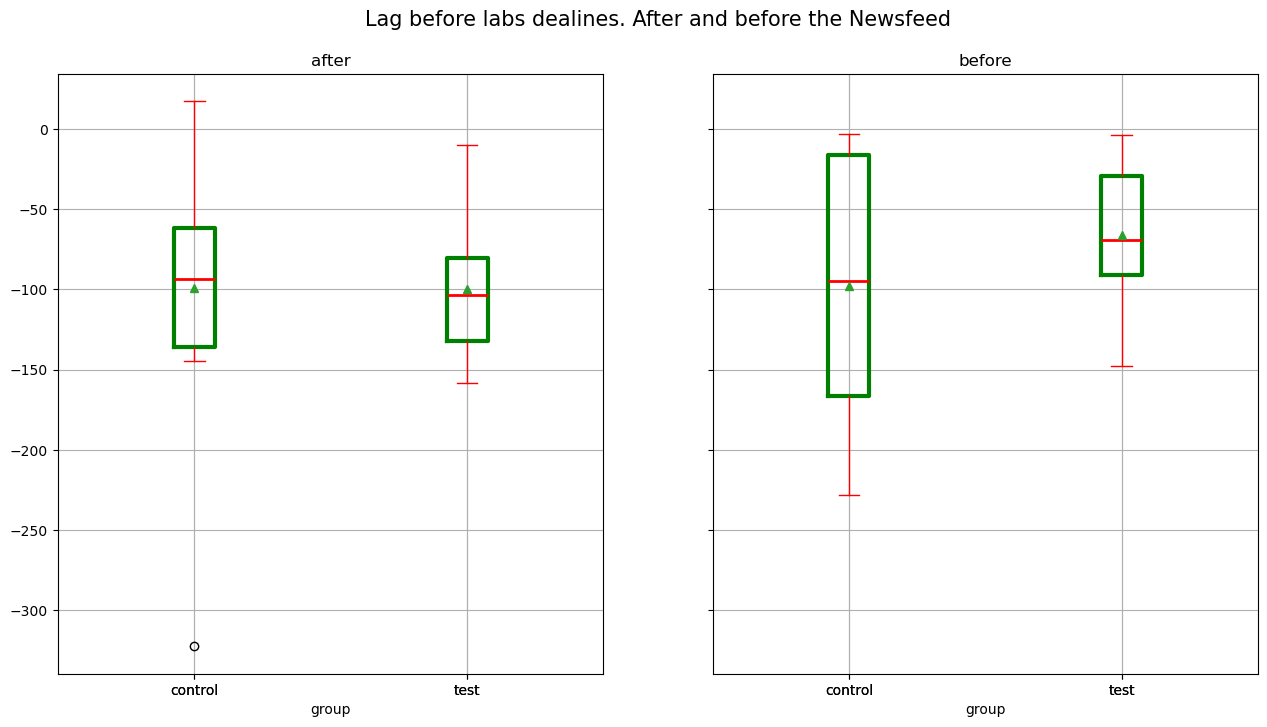

In [88]:
box_data.boxplot(column=['after','before'], by='group',
                 showmeans=True,
                 medianprops=dict(linewidth=2, color='red'),
                 boxprops=dict(linewidth=3, color='green'),
                 whiskerprops=dict(color='red'),
                 capprops=dict(color='red'),
                 figsize=(15,8))
plt.suptitle('Lag before labs dealines. After and before the Newsfeed', size=15)
plt.show()

In [ ]:
conn.close()

## What was the IQR of the control group before the newsfeed?

## IQR approximately equal to 150